# Run first

In [1]:
import yt 
import numpy as np

def _gamma(field, data):
    u1 = data[('gas', 'four_velocity_r')]
    u2 = data[('gas', 'four_velocity_theta')]
    u3 = data[('gas', 'four_velocity_z')]
    c = data.ds.quan(1.0, 'code_velocity')
    return (1 + (u1/c)**2 + (u2/c)**2 + (u3/c)**2)**0.5


yt.add_field(('gas', 'lorentz_gamma'), function=_gamma, units="", sampling_type = "cell", dimensions = yt.units.dimensionless)
# Cartesian velocity components derived directly from the native cylindrical fields.
# ('athena_pp', 'vel1') = v_R,  ('athena_pp', 'vel2') = v_phi
# ('index', 'theta')    = azimuthal angle phi of each cell
# v_x = v_R*cos(phi) - v_phi*sin(phi)
# v_y = v_R*sin(phi) + v_phi*cos(phi)
def _vel_cyl_x(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.cos(phi) - vphi * np.sin(phi)

def _vel_cyl_y(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.sin(phi) + vphi * np.cos(phi)

yt.add_field(('gas', 'vel_cyl_x'), function=_vel_cyl_x,
             units='code_velocity', sampling_type='cell', force_override=True)
yt.add_field(('gas', 'vel_cyl_y'), function=_vel_cyl_y,
             units='code_velocity', sampling_type='cell', force_override=True)

In [2]:
def _enthalpy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return 1 + 4*P/(rho*c**2)


yt.add_field(('gas', 'enthalpy'), function=_enthalpy, units="", sampling_type="cell", dimensions=yt.units.dimensionless)

def _entropy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return P/rho**(4/3)

yt.add_field(('gas', 'entropy'), function=_entropy, units="code_length**3/(code_mass**(1/3)*code_time**2)", sampling_type="cell")

# ds/dt

yt : [WARNING  ] 2026-07-09 14:43:34,460 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:34,462 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:34,463 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:34,463 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-07-09 14:43:34,501 Parameters: current_time              = 1.200000624979218
yt : [INFO     ] 2026-07-09 14:43:34,501 Parameters: domain_dimensions         = [2400 1600    1]
yt : [INFO     ] 2026-07-09 14:43:34,503 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-07-09 14:43:34,503 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-07-09 14:43:34,504 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-07-09 14:43:34,563 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:34,563 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:34,563 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:34,564 Assuming 1.0 = 1.0 K
yt : 


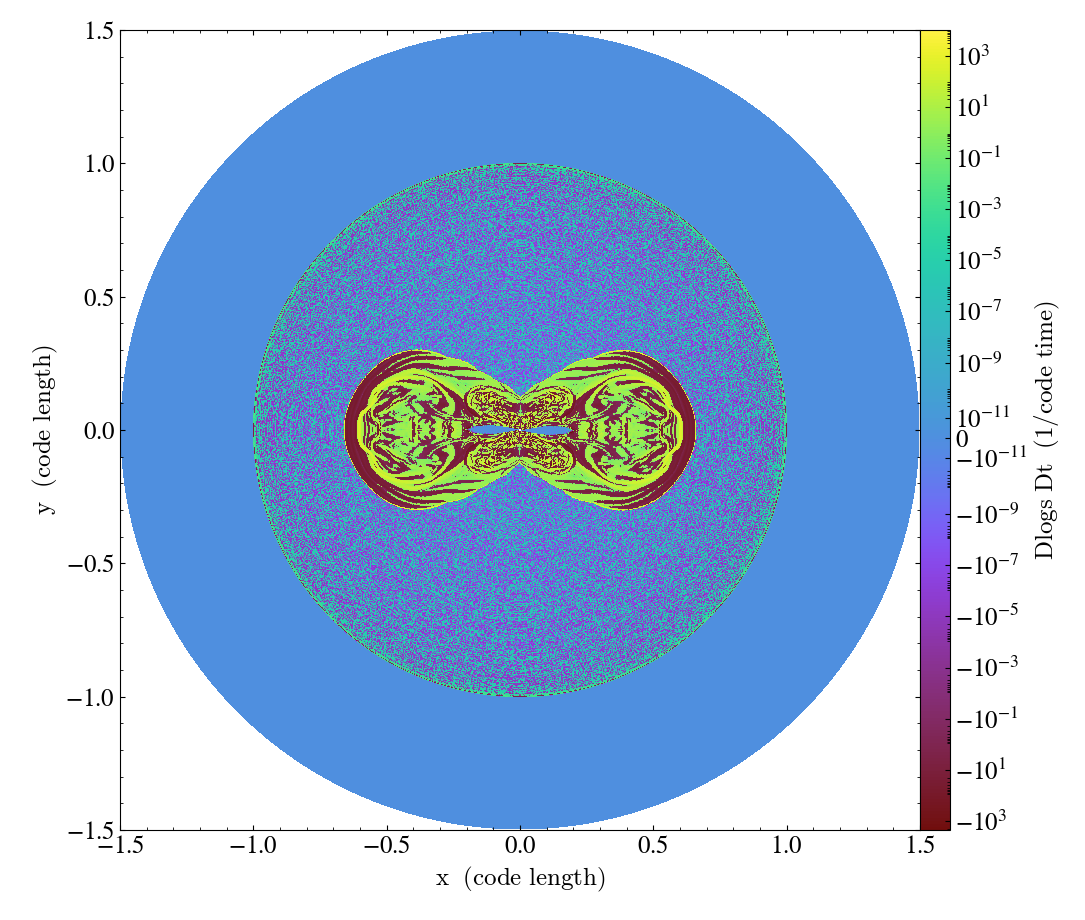

In [3]:

ds1 = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.01200.athdf')
ds2 = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.01201.athdf')
dt = float(ds2.current_time - ds1.current_time)
dims = ds1.domain_dimensions
le, re = ds1.domain_left_edge.v, ds1.domain_right_edge.v

cg1 = ds1.covering_grid(0, left_edge=ds1.domain_left_edge, dims=dims)
cg2 = ds2.covering_grid(0, left_edge=ds2.domain_left_edge, dims=dims)

dlogS_dt_arr = (np.log(cg2[('gas', 'entropy')].v) - np.log(cg1[('gas', 'entropy')].v)) / dt

def _dlogS_dt(field, data):
    pts = data.fcoords.v
    i0 = np.clip(((pts[:, 0] - le[0]) / (re[0] - le[0]) * dims[0]).astype(int), 0, dims[0]-1)
    i1 = np.clip(((pts[:, 1] - le[1]) / (re[1] - le[1]) * dims[1]).astype(int), 0, dims[1]-1)
    return data.ds.arr(dlogS_dt_arr[i0, i1, 0], '1/code_time')


ds1.add_field(('gas', 'dlogS_dt'), function=_dlogS_dt,
              units='1/code_time', sampling_type='cell', force_override=True)
p = yt.SlicePlot(ds1, 'z', ('gas', 'dlogS_dt'))
p.show()


In [4]:
import yt, numpy as np, matplotlib.pyplot as plt

ts_diag = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
dims = ts_diag[0].domain_dimensions

# Sample ~10 pairs around the interesting time window
diag_vals = []
S_prev = None
for ds in ts_diag[1200:1220]:   # adjust index range to match t ~ 1.8–4.5
    cg = ds.covering_grid(0, left_edge=ds.domain_left_edge, dims=dims)
    S = cg[('gas', 'entropy')].v
    if S_prev is not None:
        dt = float(ds.current_time) - t_prev
        v = (np.log(S) - np.log(S_prev))[:, :, 0] / dt
        diag_vals.append(v[v > 0])   # positive only (shock heating)
    S_prev = S
    t_prev = float(ds.current_time)

all_vals = np.concatenate(diag_vals)
plt.hist(np.log10(all_vals[all_vals > 1]), bins=100)
plt.xlabel('log10(dlogS/dt)')
plt.title('Distribution of positive dlogS/dt')
plt.show()
print(f"99th pct: {np.percentile(all_vals, 99):.1e},  99.9th: {np.percentile(all_vals, 99.9):.1e}")

yt : [WARNING  ] 2026-07-09 14:43:45,271 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:45,272 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:45,272 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:45,273 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-07-09 14:43:45,296 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-07-09 14:43:45,296 Parameters: domain_dimensions         = [2400 1600    1]
yt : [INFO     ] 2026-07-09 14:43:45,296 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-07-09 14:43:45,297 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-07-09 14:43:45,297 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-07-09 14:43:45,312 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:45,313 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:45,313 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:45,313 Assuming 1.0 = 1.0 K
yt : [INFO     ] 20

yt : [WARNING  ] 2026-07-09 14:43:48,600 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:48,601 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:48,601 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:48,601 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-07-09 14:43:48,621 Parameters: current_time              = 1.2010008716237865
yt : [INFO     ] 2026-07-09 14:43:48,621 Parameters: domain_dimensions         = [2400 1600    1]
yt : [INFO     ] 2026-07-09 14:43:48,622 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-07-09 14:43:48,622 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-07-09 14:43:48,622 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-07-09 14:43:52,530 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:43:52,532 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:43:52,532 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:43:52,532 Assuming 1.0 = 1.0 K
yt :

KeyboardInterrupt: 

In [ ]:
import yt
import numpy as np
import pandas as pd

THRESHOLD = 1e3
OUT_CSV   = '/scratch/aripoll/athena_out/outputs/dt_shock_track.csv'

ts   = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
dims = ts[0].domain_dimensions  # (nr, nphi, 1)

# Build coordinate arrays once — fixed grid, same for every timestep
ds0     = ts[0]
le, re  = ds0.domain_left_edge.v, ds0.domain_right_edge.v
nr, nphi = int(dims[0]), int(dims[1])

r_arr       = le[0] + (np.arange(nr)   + 0.5) * (re[0] - le[0]) / nr
phi_arr     = le[1] + (np.arange(nphi) + 0.5) * (re[1] - le[1]) / nphi
phi_deg_arr = np.degrees(phi_arr)

# Write header once before the loop
pd.DataFrame(columns=['time', 'r', 'phi_deg', 'dlogS_dt']).to_csv(OUT_CSV, index=False)

S_prev = None
t_prev = None
total_rows = 0

for ds in ts[3000:5000]:
    cg = ds.covering_grid(0, left_edge=ds.domain_left_edge, dims=dims)
    S  = cg[('gas', 'entropy')].v          # (nr, nphi, 1)
    t  = float(ds.current_time)

    if S_prev is not None:
        dt      = t - t_prev
        dlogS   = (np.log(S) - np.log(S_prev))[:, :, 0] / dt  # (nr, nphi)
        ir, iphi = np.where(dlogS > THRESHOLD)
        if len(ir):
            rows = [{'time': t_prev, 'r': r_arr[i],
                     'phi_deg': phi_deg_arr[j], 'dlogS_dt': dlogS[i, j]}
                    for i, j in zip(ir, iphi)]
            pd.DataFrame(rows).to_csv(OUT_CSV, mode='a', header=False, index=False)
            total_rows += len(rows)

    S_prev = S
    t_prev = t

print(f"Saved {total_rows:,} shock cells → {OUT_CSV}")

yt : [WARNING  ] 2026-07-09 14:48:13,467 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:48:13,468 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:48:13,468 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:48:13,468 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-07-09 14:48:13,489 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-07-09 14:48:13,489 Parameters: domain_dimensions         = [2400 1600    1]
yt : [INFO     ] 2026-07-09 14:48:13,489 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-07-09 14:48:13,489 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-07-09 14:48:13,489 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-07-09 14:48:13,492 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-07-09 14:48:13,492 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-07-09 14:48:13,493 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-07-09 14:48:13,493 Assuming 1.0 = 1.0 K
yt : [INFO     ] 20

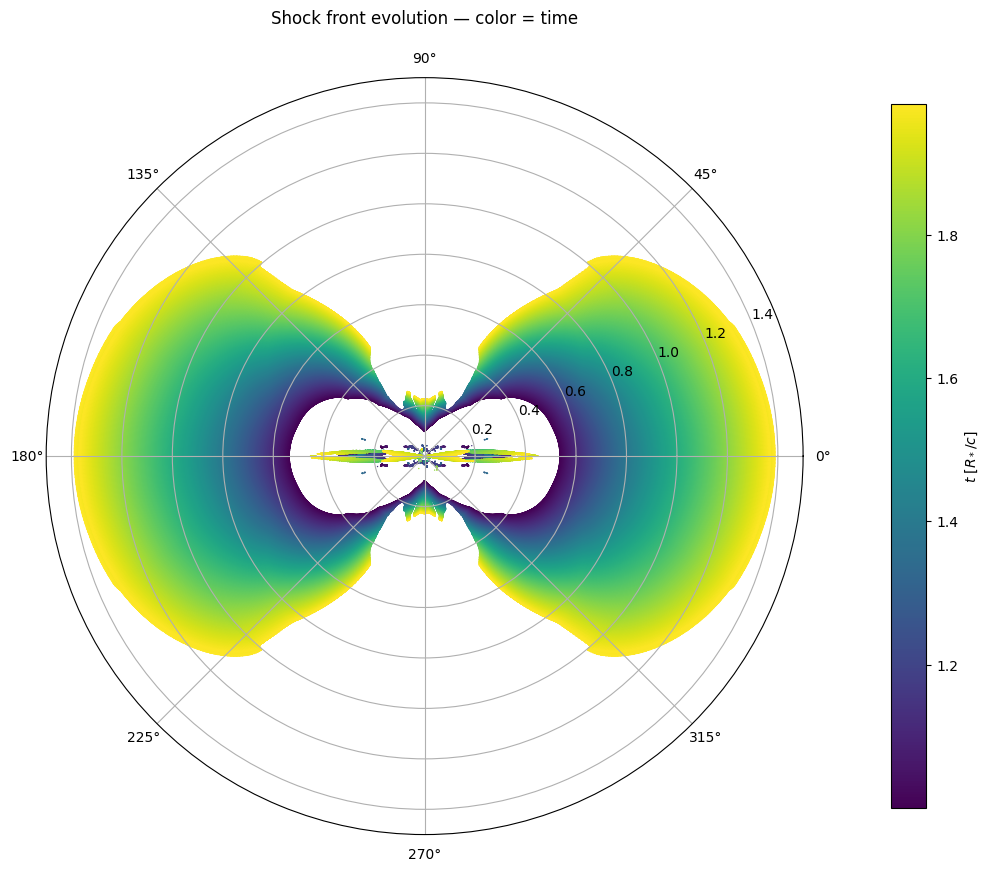

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

dt_fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/dt_shock_track.csv')

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 10))

sc = ax.scatter(
    np.deg2rad(dt_fronts['phi_deg']),
    dt_fronts['r'],
    c=dt_fronts['time'],
    cmap='viridis',
    s=1,
    linewidths=0,
    rasterized=True,
)

plt.colorbar(sc, ax=ax, label=r'$t\ [R_*/c]$', fraction=0.04, pad=0.1)
ax.set_rlim(0, 1.5)
ax.set_title(r'Shock front evolution — color = time', pad=20)
plt.tight_layout()
plt.show()

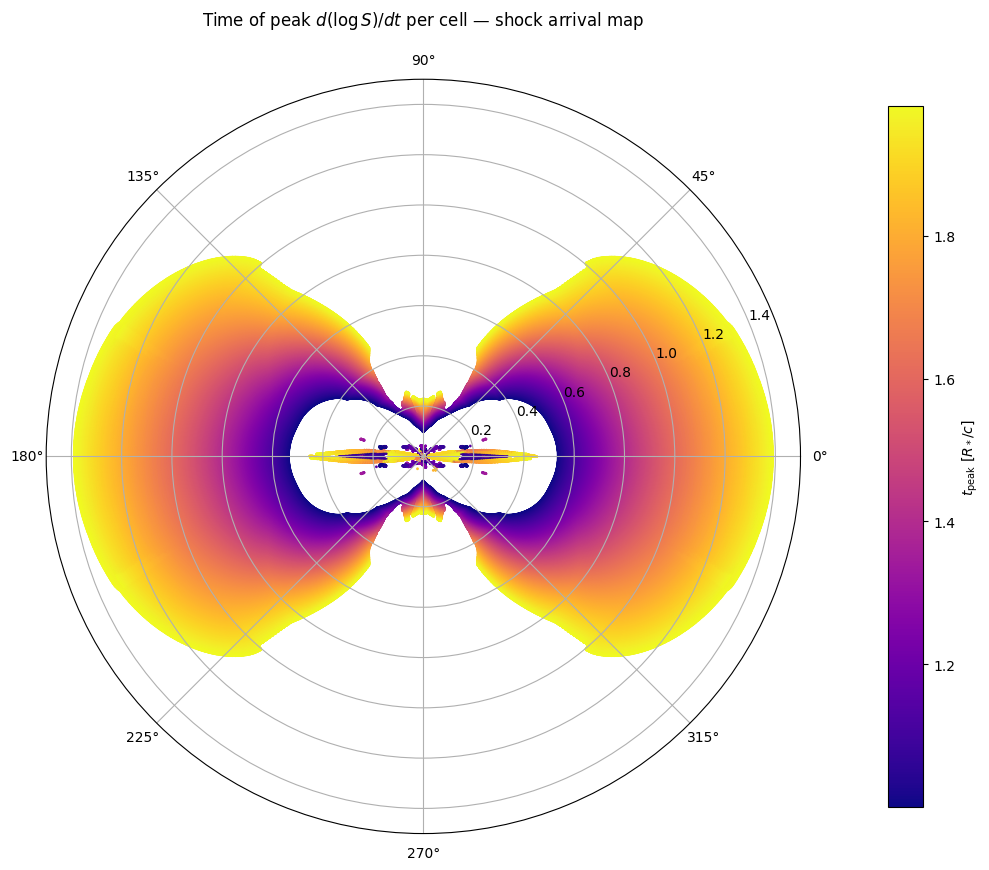

In [6]:
# For each spatial cell, find the time at which dlogS/dt was highest
peak_times = (
    dt_fronts
    .loc[dt_fronts.groupby(['r', 'phi_deg'])['dlogS_dt'].idxmax()]
    [['r', 'phi_deg', 'time', 'dlogS_dt']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 10))
sc = ax.scatter(
    np.deg2rad(peak_times['phi_deg']),
    peak_times['r'],
    c=peak_times['time'],
    cmap='plasma',
    s=4,
    linewidths=0,
    rasterized=True,
)
plt.colorbar(sc, ax=ax, label=r'$t_{\rm peak}\ [R_*/c]$', fraction=0.04, pad=0.1)
ax.set_rlim(0, 1.5)
ax.set_title(r'Time of peak $d(\log S)/dt$ per cell — shock arrival map', pad=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2954437/2845179237.py:26: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / grad_mag


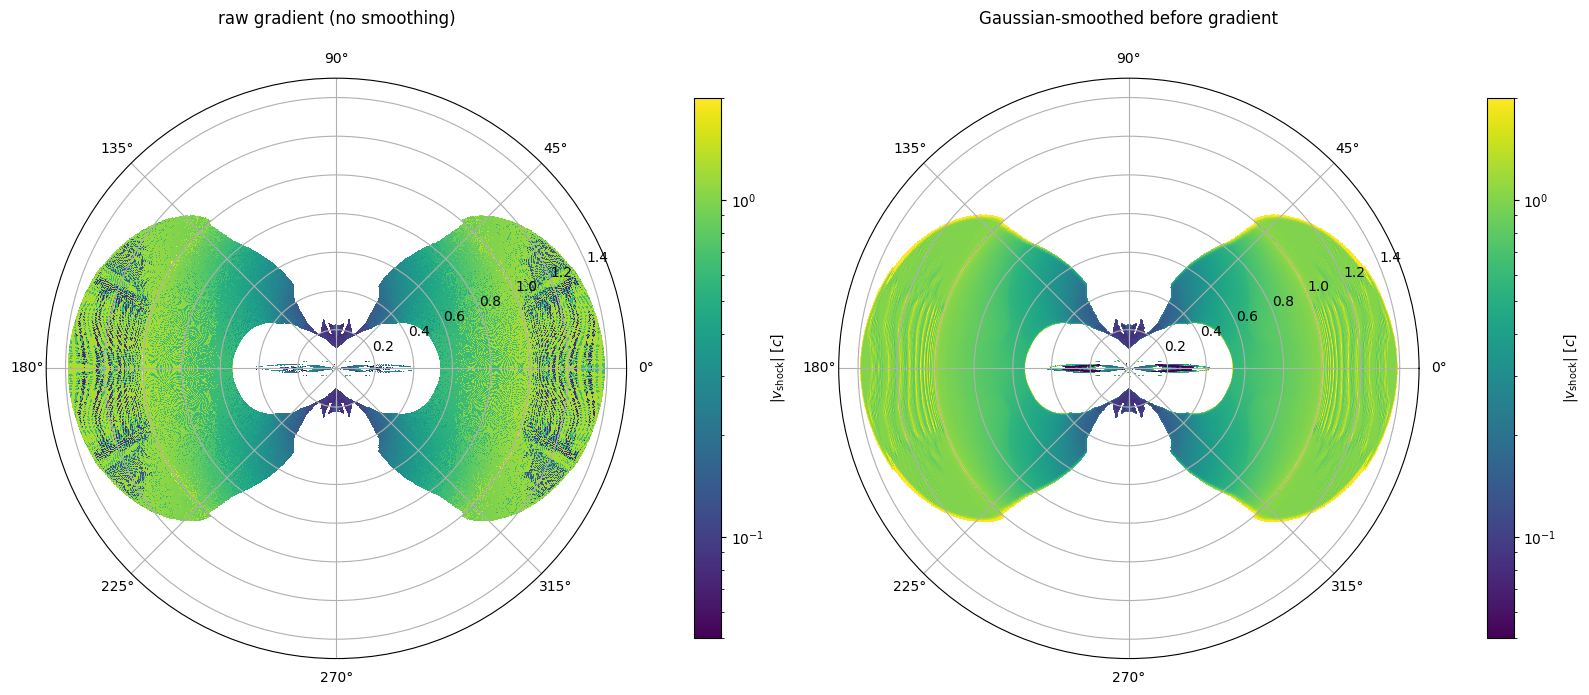

raw:      median=0.604 c,  frac > c = 11.11%
smoothed: median=0.709 c,  frac > c = 7.71%


In [7]:
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# --- Grid the scattered peak-arrival times onto the fixed (r, phi) mesh ---
# (r, phi_deg) values already sit on the simulation's regular grid; only cells that
# actually crossed the dlogS/dt threshold appear in peak_times, so missing
# combinations become NaN ("never shocked in the recorded window").
r_grid   = np.sort(peak_times['r'].unique())
phi_grid = np.sort(peak_times['phi_deg'].unique())
phi_rad  = np.deg2rad(phi_grid)
dphi     = phi_rad[1] - phi_rad[0]

T = (
    peak_times
    .pivot(index='r', columns='phi_deg', values='time')
    .reindex(index=r_grid, columns=phi_grid)
    .to_numpy()
)  # shape (nr, nphi)
mask = ~np.isnan(T)

def eikonal_speed(T, r_grid, dphi):
    """v = 1/|grad T|, grad T = (dT/dr, (1/r) dT/dphi); phi wraps (periodic domain)."""
    dTdr   = np.gradient(T, r_grid, axis=0)
    dTdphi = (np.roll(T, -1, axis=1) - np.roll(T, 1, axis=1)) / (2 * dphi)
    grad_mag = np.sqrt(dTdr**2 + (dTdphi / r_grid[:, None])**2)
    return 1.0 / grad_mag

# ---------- Method 1: raw finite differences on the un-smoothed arrival map ----------
v_raw = eikonal_speed(T, r_grid, dphi)
v_raw[~mask] = np.nan

# ---------- Method 2: smooth the arrival-time surface first, then differentiate ----------
# Normalized convolution: smooth the data and the mask with the same Gaussian kernel so
# NaN (unshocked) cells don't bias the result; mode='wrap' on the phi axis respects periodicity.
sigma = 3  # grid cells; raise to suppress more noise at the cost of front sharpness
filled     = np.where(mask, T, 0.0)
weight     = gaussian_filter(mask.astype(float), sigma=sigma, mode=['nearest', 'wrap'])
smooth_num = gaussian_filter(filled, sigma=sigma, mode=['nearest', 'wrap'])
with np.errstate(invalid='ignore', divide='ignore'):
    T_smooth = smooth_num / weight
T_smooth[weight < 0.3] = np.nan  # too little real data nearby to trust the smoothed value

v_smooth = eikonal_speed(T_smooth, r_grid, dphi)
v_smooth[np.isnan(T_smooth)] = np.nan

# ---------- Compare ----------
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(16, 8))
for ax, v, title in zip(axes, [v_raw, v_smooth],
                         ['raw gradient (no smoothing)', 'Gaussian-smoothed before gradient']):
    pm = ax.pcolormesh(
        phi_rad, r_grid, v,
        cmap='viridis', norm=mcolors.LogNorm(vmin=0.05, vmax=2.0), shading='auto',
    )
    plt.colorbar(pm, ax=ax, label=r'$|v_{\rm shock}|\ [c]$', fraction=0.04, pad=0.1)
    ax.set_rlim(0, 1.5)
    ax.set_title(title, pad=20)
plt.tight_layout()
plt.show()

print(f"raw:      median={np.nanmedian(v_raw):.3f} c,  frac > c = {np.nanmean(v_raw > 1):.2%}")
print(f"smoothed: median={np.nanmedian(v_smooth):.3f} c,  frac > c = {np.nanmean(v_smooth > 1):.2%}")

In [6]:
import subprocess
from pathlib import Path

frames_dir = Path('/scratch/aripoll/athena_out/frames_dt')
frames_dir.mkdir(parents=True, exist_ok=True)

times = sorted(dt_fronts['time'].unique())

for i, t in enumerate(times):
    frame = dt_fronts[dt_fronts['time'] == t]

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(14, 14))
    ax.scatter(
        np.deg2rad(frame['phi_deg']),
        frame['r'],
        c=frame['dlogS_dt'],
        cmap='inferno',
        norm=mcolors.LogNorm(vmin=1e3, vmax=dt_fronts['dlogS_dt'].quantile(0.999)),
        s=8,
        linewidths=0,
    )
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front  $t = {t:.3f}\ R_*/c$", pad=20)
    plt.tight_layout()
    plt.savefig(frames_dir / f'frame_{i:05d}.png', dpi=80)
    plt.close()

subprocess.run([
    'ffmpeg', '-y', '-framerate', '15', '-i', str(frames_dir / 'frame_%05d.png'),
    '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2',
    'dt_shock_evolution.mp4'
], check=True)

from IPython.display import Video, display
display(Video('dt_shock_evolution.mp4', embed=True))

ffmpeg version 4.4.4 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 12 (Gentoo 12.3.1_p20230526 p2)
  configuration: --prefix=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr --libdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --shlibdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib64 --docdir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/doc/ffmpeg-4.4.4-r3/html --mandir=/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/share/man --enable-shared --cc=x86_64-pc-linux-gnu-gcc --cxx=x86_64-pc-linux-gnu-g++ --ar=x86_64-pc-linux-gnu-ar --nm=x86_64-pc-linux-gnu-nm --strip=x86_64-pc-linux-gnu-strip --ranlib=x86_64-pc-linux-gnu-ranlib --pkg-config=x86_64-pc-linux-gnu-pkg-config --optflags='-O2 -pipe -march=x86-64-v3 -O2 -ftree-vectorize -fno-math-errno -pipe -O2 -pipe' --disable-static --enable-avfilter --enable-avresample --disable-stripping --disable-optimizations --disable-libcelt --disable-indev=v4l2 --disable-outdev

# Entropy Tracking

yt : [WARNING  ] 2026-05-29 14:49:06,561 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-29 14:49:06,562 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-29 14:49:06,563 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-29 14:49:06,563 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: current_time              = 0.6300002622196839
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-29 14:49:06,603 Parameters: cosmological_simulation   = 0


Shock fronts at theta=4.712 rad: 1.002 R_*
Shock fronts at theta=4.695 rad: 1.002 R_*
Shock fronts at theta=4.677 rad: 1.002 R_*
Shock fronts at theta=4.660 rad: 1.002 R_*
Shock fronts at theta=4.642 rad: 1.002 R_*
Shock fronts at theta=4.625 rad: 1.002 R_*
Shock fronts at theta=4.607 rad: 1.002 R_*
Shock fronts at theta=4.590 rad: 1.002 R_*
Shock fronts at theta=4.572 rad: 1.002 R_*
Shock fronts at theta=4.554 rad: 1.002 R_*
Shock fronts at theta=4.537 rad: 1.002 R_*
Shock fronts at theta=4.519 rad: 1.002 R_*
Shock fronts at theta=4.502 rad: 1.002 R_*
Shock fronts at theta=4.484 rad: 1.002 R_*
Shock fronts at theta=4.467 rad: 1.002 R_*
Shock fronts at theta=4.449 rad: 1.002 R_*
Shock fronts at theta=4.432 rad: 1.002 R_*
Shock fronts at theta=4.414 rad: 1.002 R_*
Shock fronts at theta=4.396 rad: 1.002 R_*
Shock fronts at theta=4.379 rad: 1.002 R_*
Shock fronts at theta=4.361 rad: 1.002 R_*
Shock fronts at theta=4.344 rad: 1.002 R_*
Shock fronts at theta=4.326 rad: 1.002 R_*
Shock front

/tmp/ipykernel_2599414/66237490.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


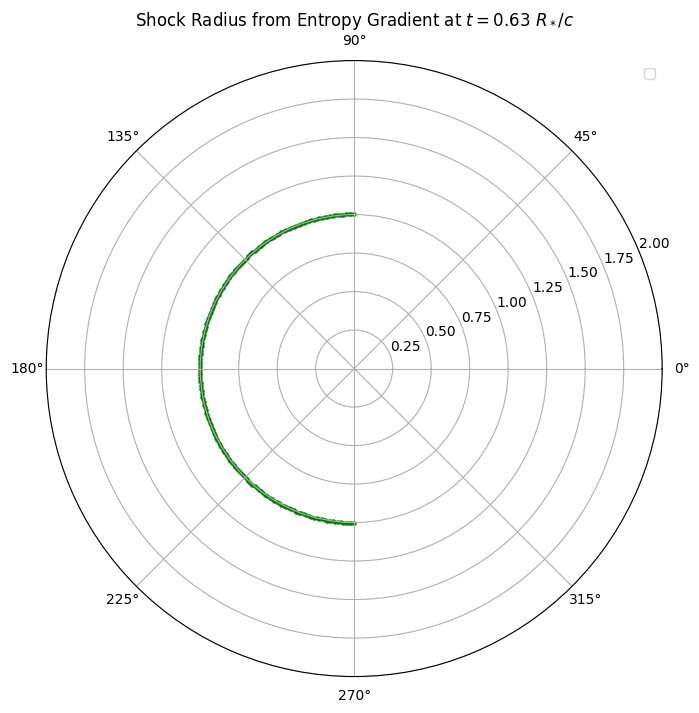

yt : [INFO     ] 2026-05-29 14:49:10,393 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,393 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,394 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-29 14:49:10,395 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,396 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,398 Making a fixed resolution buffer of (('gas', 'entropy')) 800 by 800



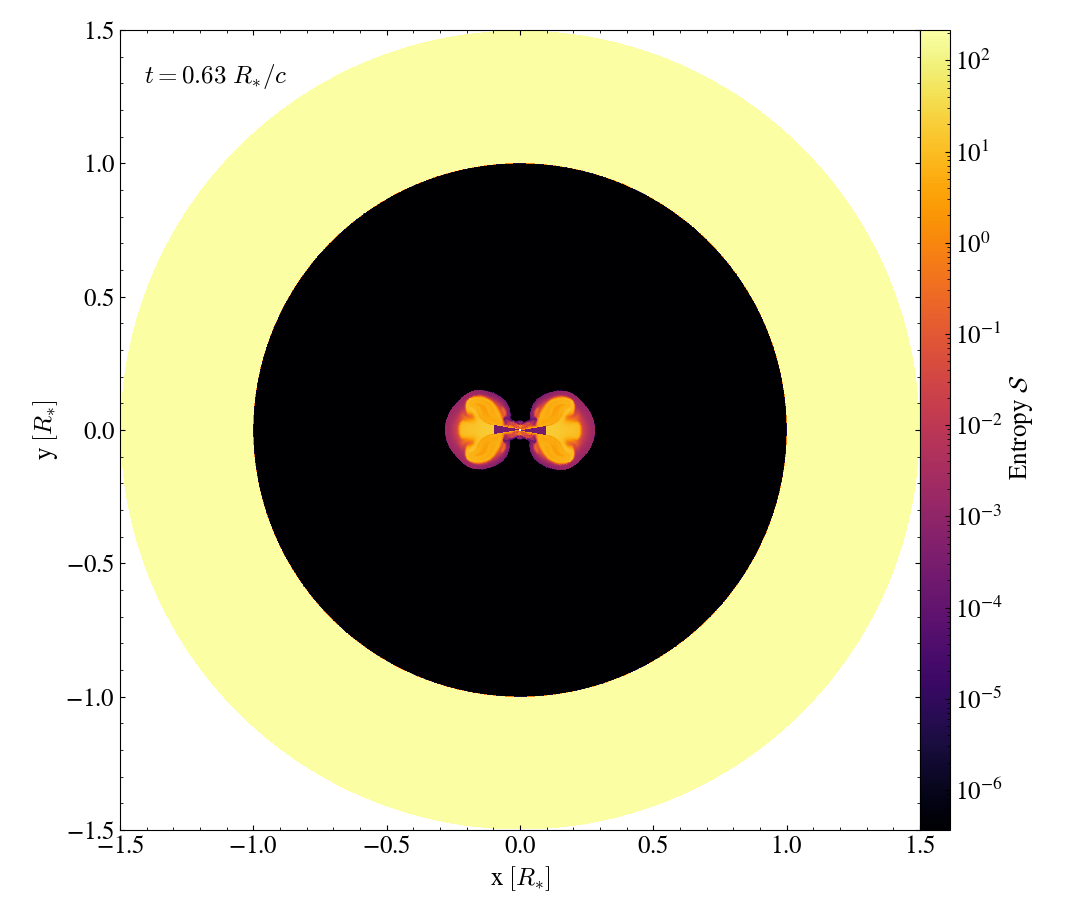

In [ ]:
import yt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1D velocity profile at a fixed azimuthal angle
theta_vals = np.linspace(3*np.pi/2, np.pi/2, 180)  # example theta values
z_val     = 0.5   #doesnt matter

ds_entr = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00630.athdf')


r_shock_entropy = []  # list of lists: 1 or more radii per theta

for theta_val in theta_vals:
    ray = ds_entr.ortho_ray(0, (theta_val, z_val))

    df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
    df_entr = df_entr.sort_values('r').reset_index(drop=True)

    if len(df_entr) < 2:
        r_shock_entropy.append([np.nan])
        continue

    # Shock has hit the surface: outer boundary entropy is still unshocked
    if np.log10(df_entr['entropy'].iloc[-1]) < 1:
        r_shock_entropy.append([1.5])
        print(f"Shock at boundary for theta={theta_val:.3f} rad")
        continue

    dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
    abs_grad = np.abs(dlogS_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    peak_radii = sorted(
        [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2],
        reverse=True
    )

    max_distance = 0.3  # tune: max allowed distance from outermost shock front

    selected = []
    if peak_radii:
        r_outer = peak_radii[0]
        selected = [r for r in peak_radii if r_outer - r <= max_distance]

    # Separately keep stellar surface peak near R=1.0
    surface_peaks = [r for r in peak_radii if 0.85 < r < 1.15]
    if surface_peaks and (not selected or min(abs(s - 1.0) for s in selected) > 0.1):
        selected.append(min(surface_peaks, key=lambda r: abs(r - 1.0)))

    radii = sorted(selected)
    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        r_shock_entropy.append(radii)
    else:
        r_shock_entropy.append([np.nan])
    # fig, ax = plt.subplots()
    # ax.plot(df_entr['r'], df_entr['entropy'], label='Entropy')
    # ax.plot(df_entr['r'], abs_grad, label='|dlogS/dr|', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Entropy $\mathcal{S}$")
    # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_entr.current_time):.2f}\ R_*/c$") 
    # ax.legend()
    # plt.show()

# Flatten for polar plot: duplicate theta for entries with two fronts
plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
plot_r     = [r  for rs in r_shock_entropy for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Entropy Gradient at $t = {float(ds_entr.current_time):.2f}\ R_*/c$")
ax.legend()
plt.show()

p = yt.SlicePlot(ds_entr, 'z', ('gas', 'entropy'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "entropy"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "entropy"), r" Entropy $\mathcal{S}$")

# Lorentz Factor tracking

yt : [WARNING  ] 2026-05-29 14:49:11,356 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-29 14:49:11,383 Parameters: current_time              = 0.9000013308920282
yt : [INFO     ] 2026-05-29 14:49:11,383 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: cosmological_simulation   = 0


Shock fronts at theta=0.386 rad: 0.203 R_*
Shock fronts at theta=0.421 rad: 0.211 R_*
Shock fronts at theta=0.527 rad: 0.238 R_*
Shock fronts at theta=0.562 rad: 0.239 R_*
Shock fronts at theta=0.597 rad: 0.239 R_*
Shock fronts at theta=0.632 rad: 0.236 R_*
Shock fronts at theta=0.667 rad: 0.225 R_*
Shock fronts at theta=2.492 rad: 0.233 R_*
Shock fronts at theta=2.527 rad: 0.238 R_*
Shock fronts at theta=2.562 rad: 0.239 R_*
Shock fronts at theta=2.598 rad: 0.239 R_*
Shock fronts at theta=2.703 rad: 0.215 R_*
Shock fronts at theta=2.738 rad: 0.206 R_*
Shock fronts at theta=3.545 rad: 0.206 R_*
Shock fronts at theta=3.580 rad: 0.215 R_*
Shock fronts at theta=3.686 rad: 0.239 R_*
Shock fronts at theta=3.721 rad: 0.239 R_*
Shock fronts at theta=3.756 rad: 0.238 R_*
Shock fronts at theta=3.791 rad: 0.233 R_*
Shock fronts at theta=5.616 rad: 0.225 R_*
Shock fronts at theta=5.651 rad: 0.236 R_*
Shock fronts at theta=5.686 rad: 0.239 R_*
Shock fronts at theta=5.722 rad: 0.239 R_*
Shock front

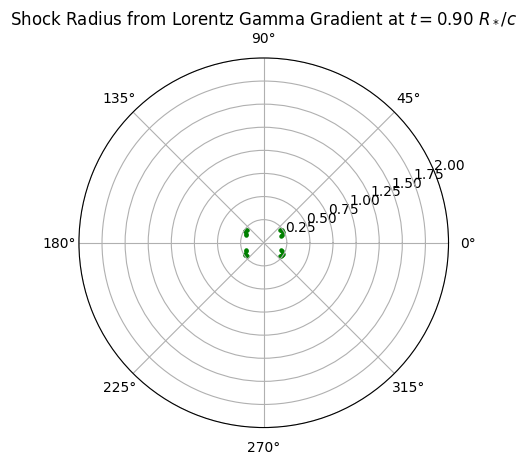

yt : [INFO     ] 2026-05-29 14:49:14,360 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,360 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,361 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-29 14:49:14,362 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,363 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,363 Making a fixed resolution buffer of (('gas', 'lorentz_gamma')) 800 by 800



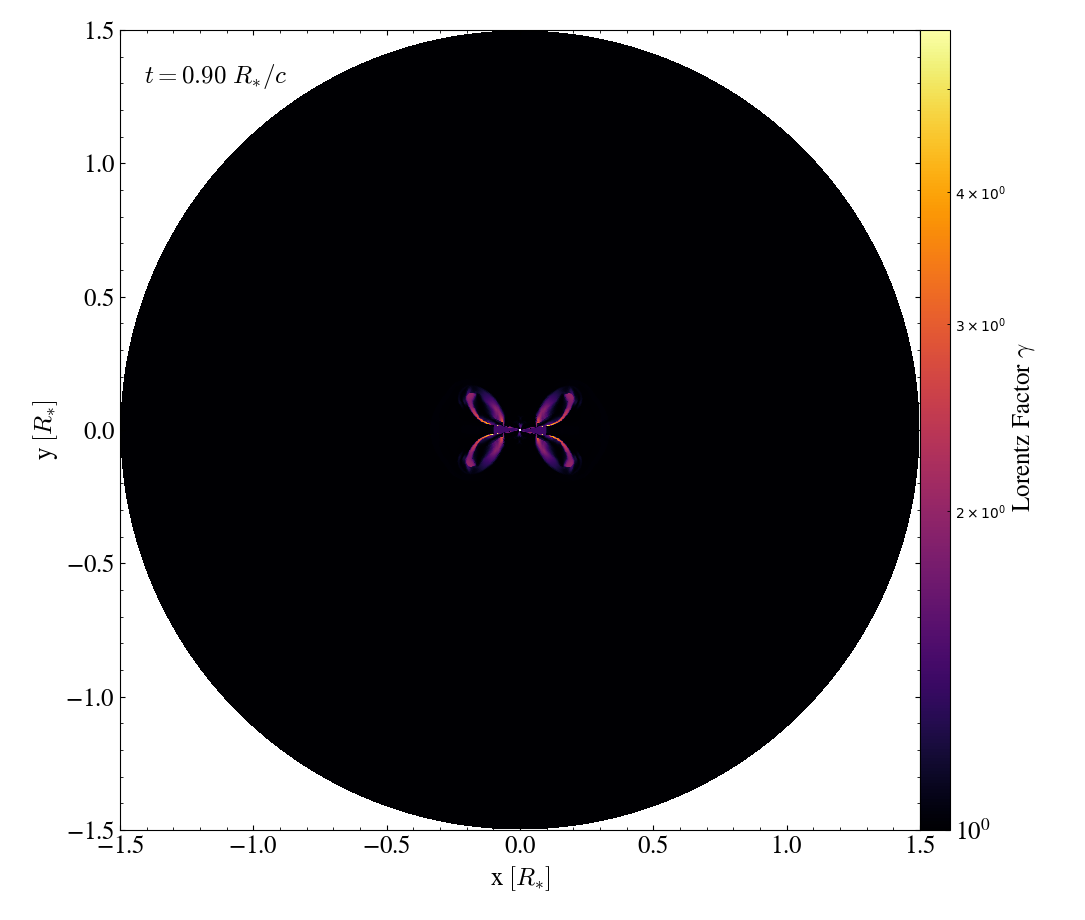

In [5]:
ds_gamma = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00900.athdf')

theta_vals = np.linspace(0, 2*np.pi, 180)  # example theta values

radii_gamma = []  # one entry per theta_val: list of radii or [nan]


for theta_val in theta_vals:
    ray = ds_gamma.ortho_ray(0, (theta_val, z_val))
    df_gamma = ray.to_dataframe([('index', 'r'), ('gas', 'lorentz_gamma')])
    df_gamma = df_gamma.sort_values('r').reset_index(drop=True)

    if len(df_gamma) < 2:
        radii_gamma.append([np.nan])  # was: bare continue (bug 1)
        continue

    dgamma_dr = np.gradient(df_gamma['lorentz_gamma'], df_gamma['r'])
    abs_grad = np.abs(dgamma_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    radii = [float(df_gamma['r'].iloc[i]) for i in peaks if df_gamma['r'].iloc[i] > 0.2]

    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        radii_gamma.append(radii)
    else:
        radii_gamma.append([np.nan])  # was: nothing (bug 2)

    # fig, ax = plt.subplots()
    # ax.plot(df_gamma['r'], df_gamma['lorentz_gamma'], label='Lorentz Gamma')
    # ax.plot(df_gamma['r'], dgamma_dr, label='dGamma/dr', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Lorentz Factor $\gamma$")
    # ax.set_title(rf"Lorentz Factor at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
    # ax.legend()
    # plt.show()

# Flatten using zip so theta tracks actual detection angles (bug 3 fix)
plot_theta = [th for th, rs in zip(theta_vals, radii_gamma) for _ in rs]
plot_r     = [r  for rs in radii_gamma for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Lorentz Gamma Gradient at $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
plt.show()

p = yt.SlicePlot(ds_gamma, 'z', ('gas', 'lorentz_gamma'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "lorentz_gamma"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "lorentz_gamma"), r" Lorentz Factor $\gamma$")


# The in-sim tracking

Requested t=2.6000, using t=2.5996  (421 fronts)


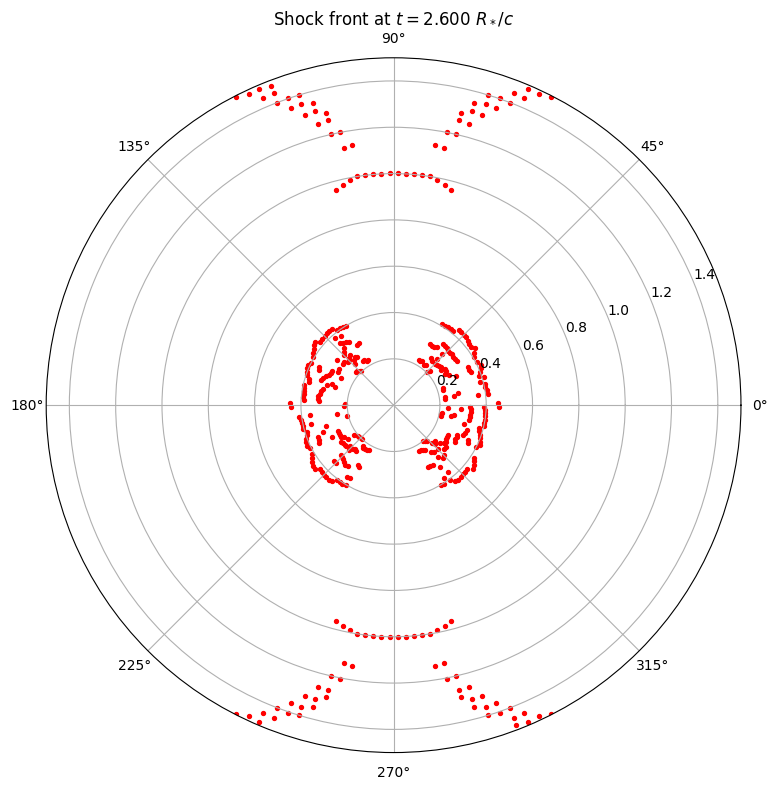

,angle_deg,r_shock,vr,v_tang,mushroom
time,,,,,
2.59964,1,0.450407,0.808205,-0.472644,0
2.59964,7,0.412347,0.481675,-0.484743,0
2.59964,7,0.368431,0.101582,0.053235,0
2.59964,7,0.222044,0.086144,-0.085771,0
2.59964,9,0.406491,0.414131,-0.555896,0
...,...,...,...,...,...
2.59964,357,0.292310,0.304568,0.327302,0
2.59964,357,0.236683,0.186151,-0.133082,0
2.59964,359,0.453335,0.714586,-0.399286,0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/shock_front.csv', index_col=0)

def get_fronts_at(t):
    """Return shock front rows at the timestep closest to t."""
    times = fronts.index.unique()
    closest_t = times[np.argmin(np.abs(times - t))]
    df = fronts.loc[[closest_t]]
    print(f"Requested t={t:.4f}, using t={closest_t:.4f}  ({len(df)} fronts)")
    return df

def plot_fronts_at(t):
    df = get_fronts_at(t)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.scatter(np.deg2rad(df['angle_deg']), df['r_shock'], marker='o', s=8, c='red')
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front at $t = {df.index[0]:.3f}\ R_*/c$")
    plt.tight_layout()
    plt.show()
    return df

# --- usage: change t_query to inspect any time ---
t_query = 2.6
df = plot_fronts_at(t_query)
df

## Find Cells that have a ds/dt over a certain threshold, that will be the shock front. We can just track all cells, find when they have a ds/dt

Requested t=1.8000, using t=1.8004  (232 fronts)


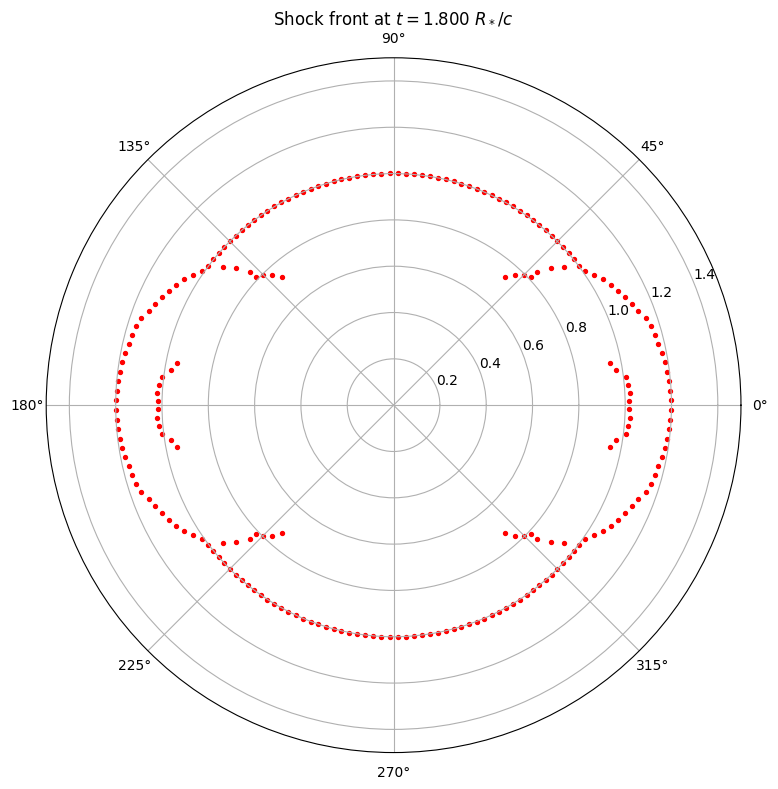

Requested t=2.1000, using t=2.0995  (224 fronts)


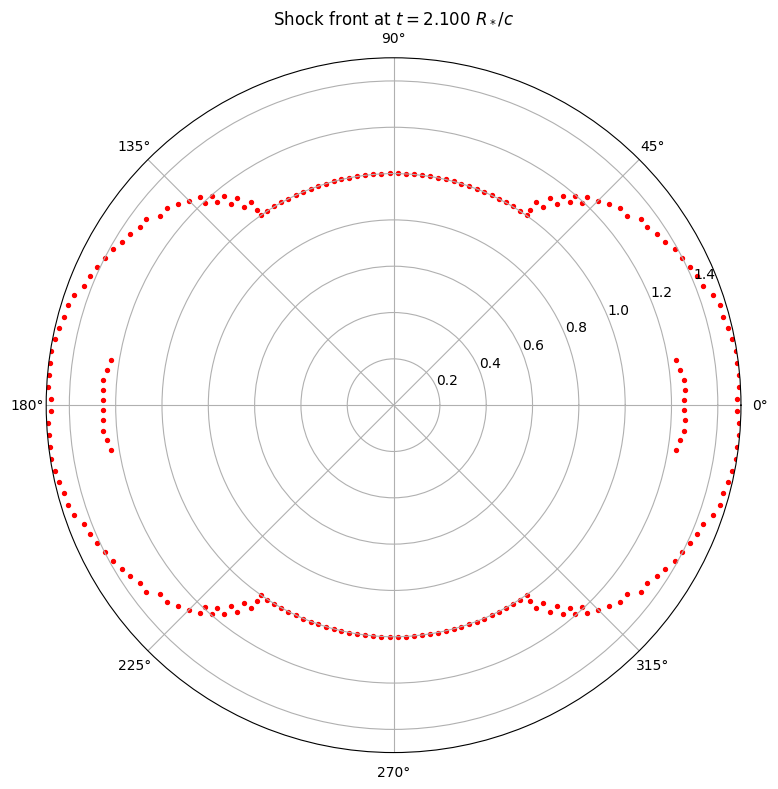

Requested t=2.4000, using t=2.3996  (313 fronts)


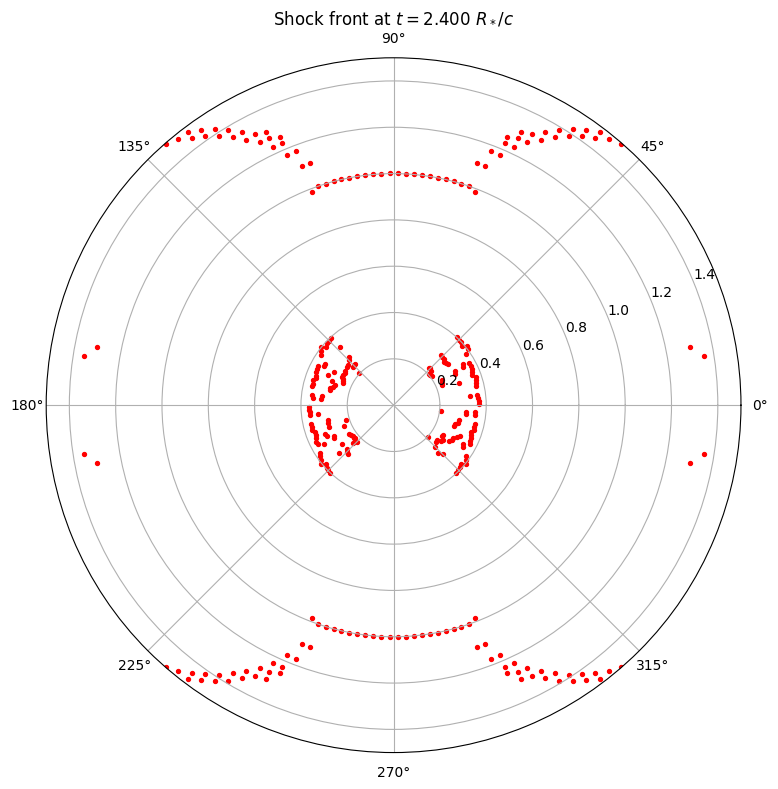

Requested t=2.7000, using t=2.6997  (443 fronts)


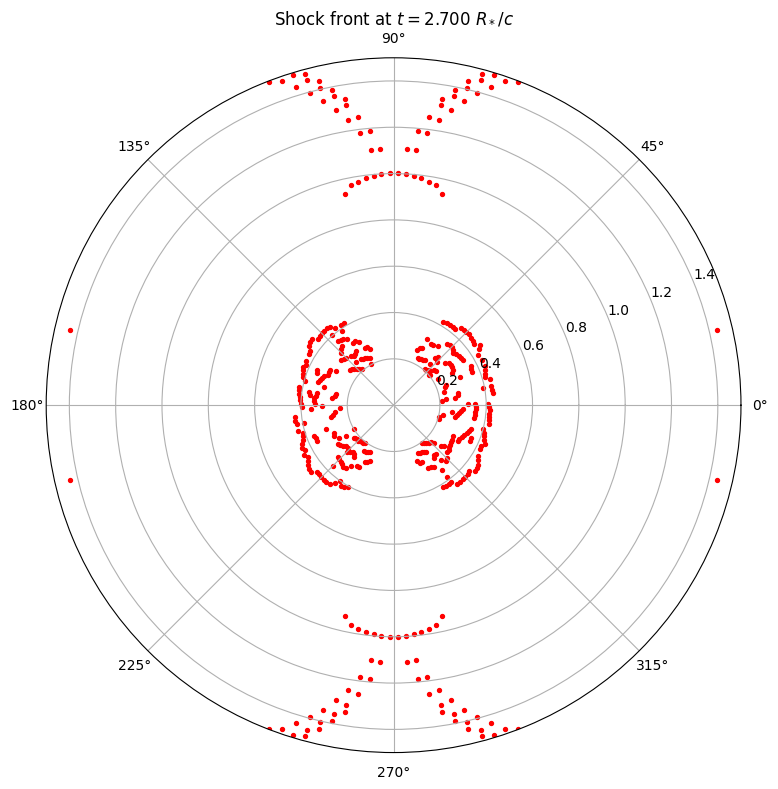

Requested t=3.0000, using t=2.9997  (369 fronts)


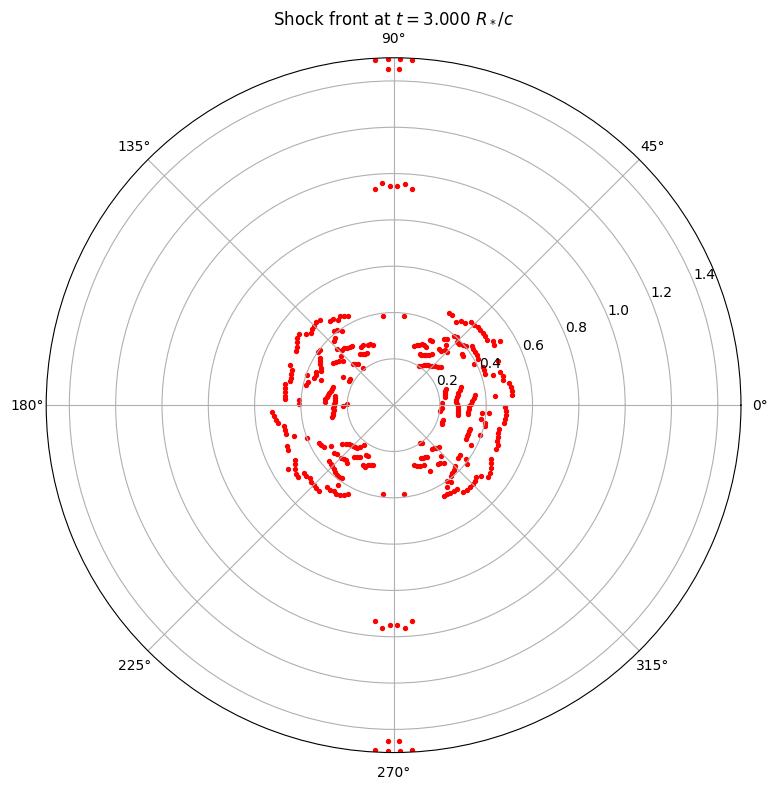

Requested t=3.3000, using t=3.2998  (330 fronts)


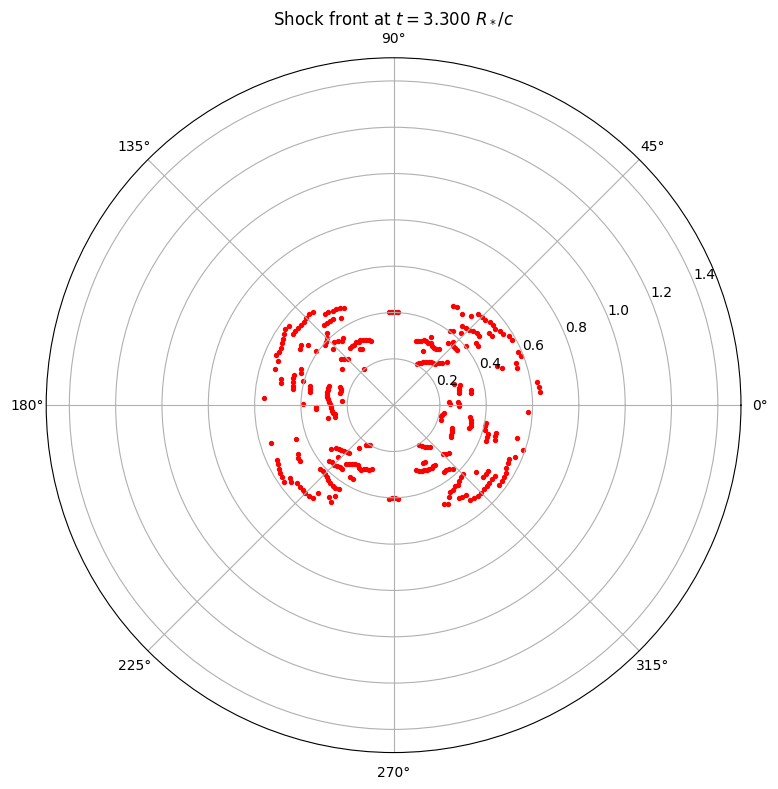

Requested t=3.6000, using t=3.5689  (300 fronts)


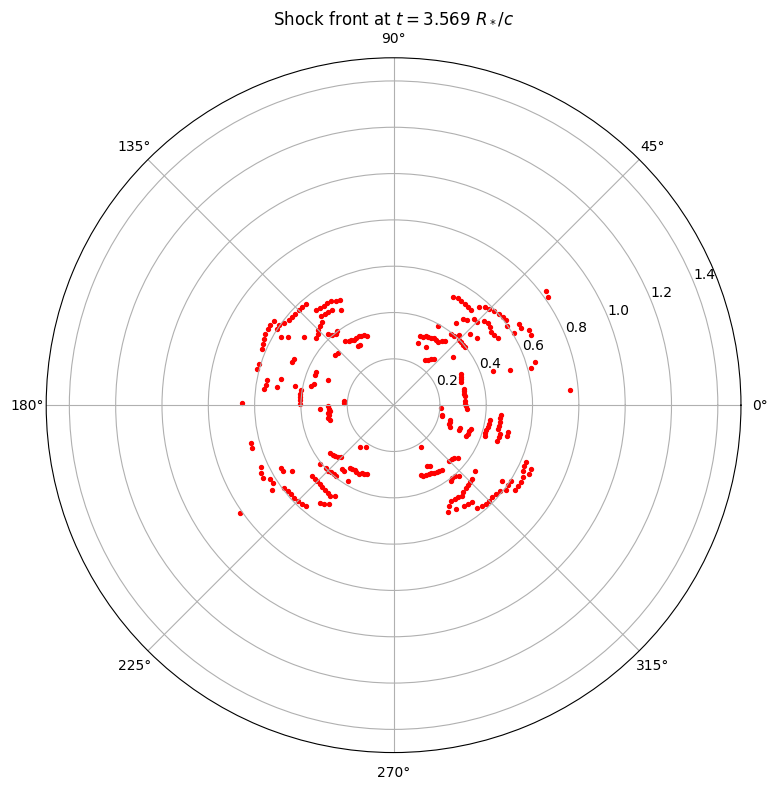

Requested t=3.9000, using t=3.5689  (300 fronts)


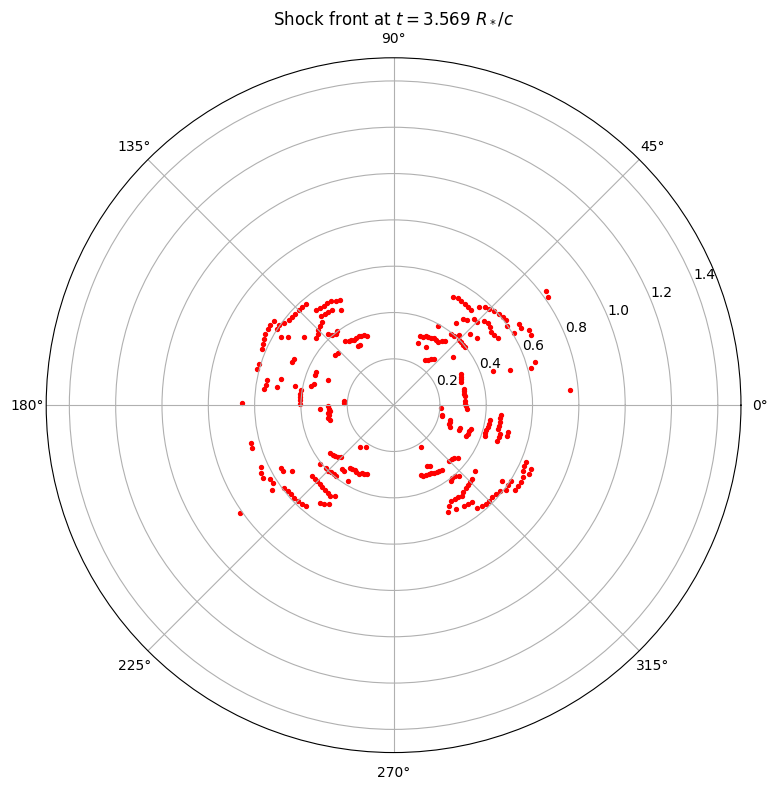

Requested t=4.2000, using t=3.5689  (300 fronts)


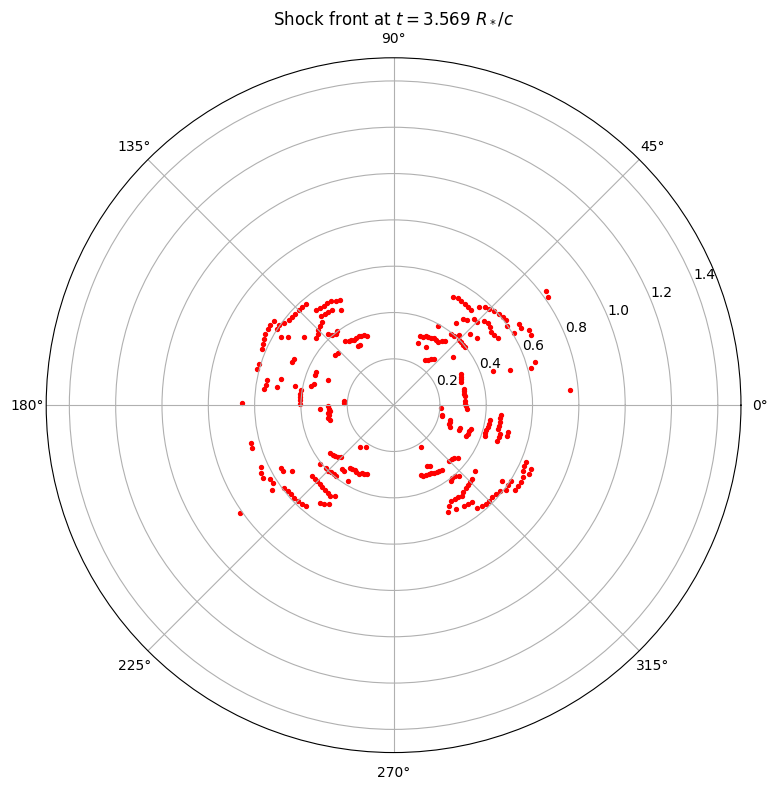

Requested t=4.5000, using t=3.5689  (300 fronts)


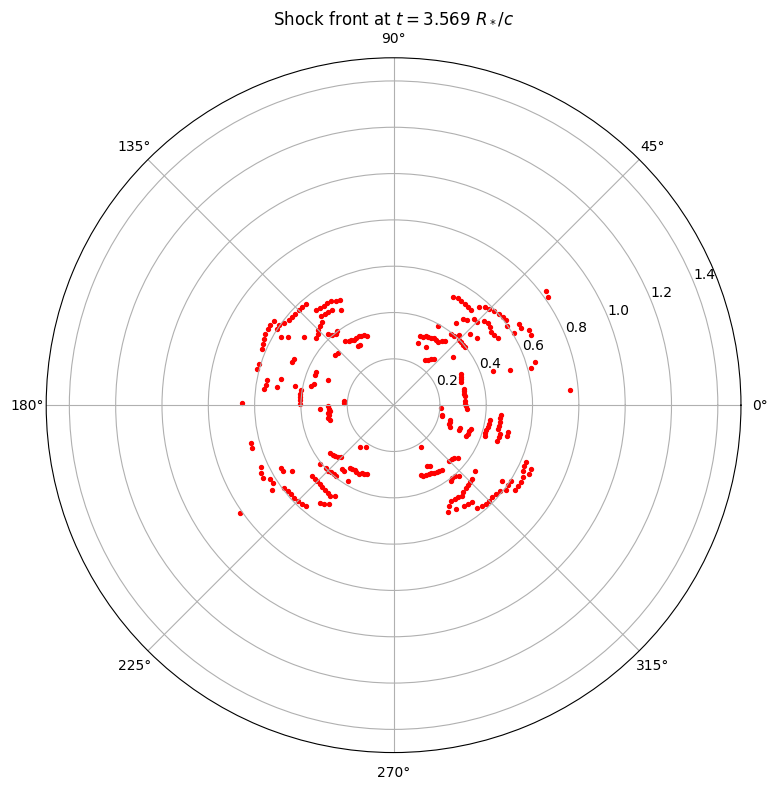

In [46]:
#Find cells that have ds/dt




#Now make a movie of the shock front evolution
t = np.linspace(1.8, 4.5, 10)
for t in t:
    plot_fronts_at(t)

In [52]:
dr = (1.5 - 1e-3) / 2400
dr

0.0006245833333333333

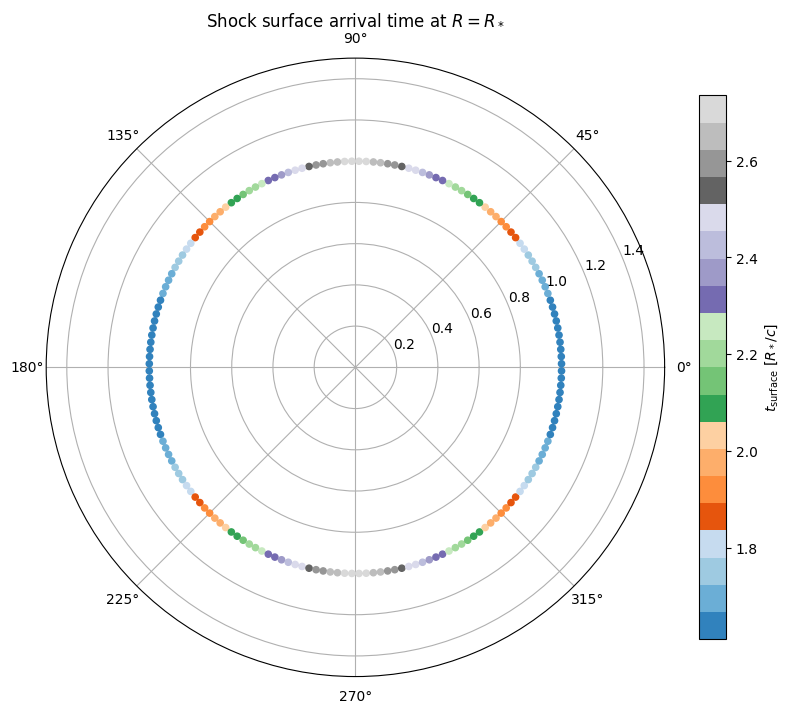

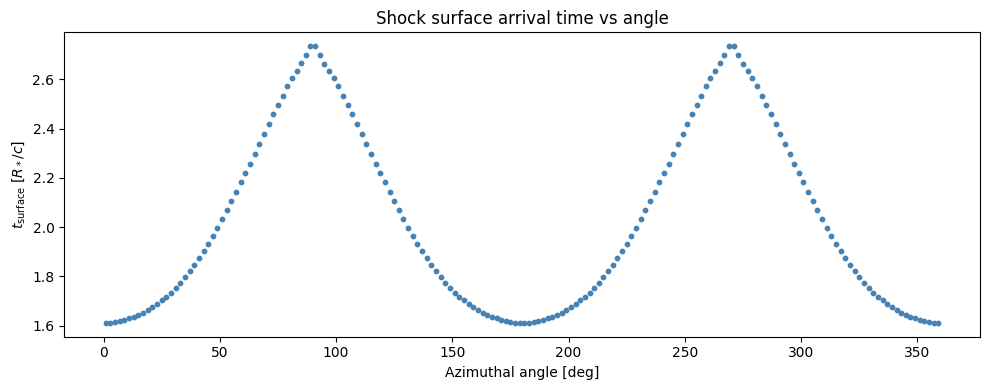

        time  angle_deg  r_shock        vr    v_tang  mushroom     v_mag
0    1.61140          1  1.00375  2.923690  0.054936         0  2.924206
1    1.61240          3  1.00375  2.690280  0.149299         0  2.694420
2    1.61540          5  1.00375  2.801240  0.247515         0  2.812154
3    1.61940          7  1.00375  2.717440  0.322128         0  2.736466
4    1.62440          9  1.00375  2.765460  0.398536         0  2.794029
5    1.62940         11  1.00375  2.396730  0.360710         0  2.423722
6    1.63540         13  1.00375  2.407010  0.387806         0  2.438051
7    1.64140         15  1.00375  1.900150  0.361926         0  1.934311
8    1.65341         17  1.00375  3.695650  0.898339         0  3.803267
9    1.66441         19  1.00375  3.767140  1.107090         0  3.926448
10   1.67441         21  1.00375  3.504930  1.206760         0  3.706859
11   1.68942         23  1.00375  3.604150  1.444070         0  3.882684
12   1.70342         25  1.00375  3.451950  1.56273

In [10]:
def surface_arrival_rows(r_tol=0.005):
    """
    For each angular bin, find the timestep of peak velocity magnitude near R=1.
    Peak |v| marks when the shock is actively crossing the cell, not just nearby.
    """
    near = fronts[np.abs(fronts['r_shock'] - 1.0) < r_tol].reset_index()
    near['v_mag'] = np.sqrt(near['vr']**2 + near['v_tang']**2)
    return near.loc[near.groupby('angle_deg')['v_mag'].idxmax()].reset_index(drop=True)

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
arr


# Polar plot: each angle dot coloured by arrival time
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
sc = ax.scatter(
    np.deg2rad(arr['angle_deg']), np.ones(len(arr)),
    c=arr['time'], cmap='tab20c', s=20, zorder=3
)
ax.set_rlim(0, 1.5)
ax.set_title(r"Shock surface arrival time at $R = R_*$")
plt.colorbar(sc, ax=ax, label=r'$t_{\rm surface}\ [R_*/c]$', fraction=0.04)
plt.tight_layout()
plt.show()

# Cartesian: angle vs arrival time (easier to read exact values)
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(arr['angle_deg'], arr['time'], s=10, c='steelblue')
ax.set_xlabel(r'Azimuthal angle [deg]')
ax.set_ylabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_title(r'Shock surface arrival time vs angle')
plt.tight_layout()
plt.show()

print(arr.to_string())

In [50]:
dr = (1.5 - 1e-3) / 2400
dr

0.0006245833333333333

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_font'

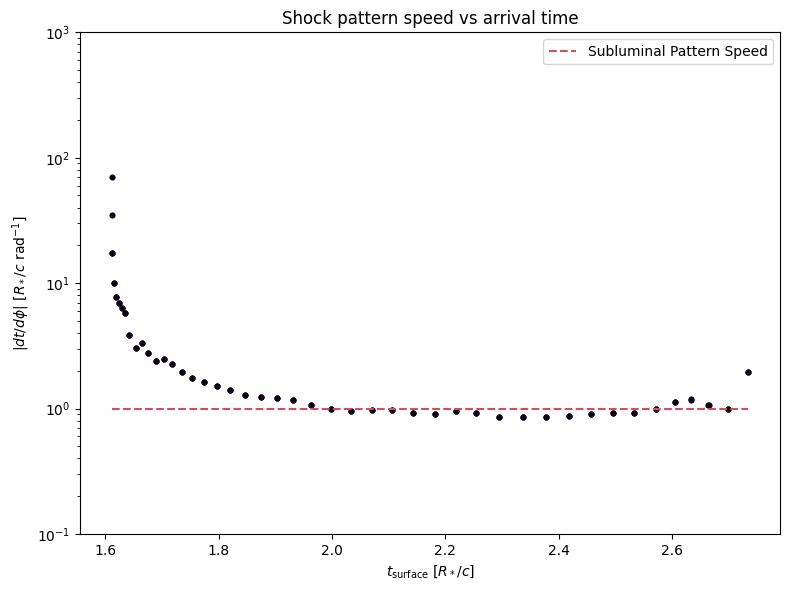

In [11]:
def surface_arrival_rows(r_tol=0.005):
    """
    For each angular bin, find the timestep of peak velocity magnitude near R=1.
    Peak |v| marks when the shock is actively crossing the cell, not just nearby.
    """
    near = fronts[np.abs(fronts['r_shock'] - 1.0) < r_tol].reset_index()
    near['v_mag'] = np.sqrt(near['vr']**2 + near['v_tang']**2)
    return near.loc[near.groupby('angle_deg')['v_mag'].idxmax()].reset_index(drop=True)

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
arr

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
phi_rad = np.deg2rad(arr['angle_deg'].values)
t_surf  = arr['time'].values

# ---- 1. Pattern speed: t_surface vs 1/speed = dt/dphi ----
dt_dphi = np.gradient(t_surf, phi_rad)          # [R_*/c per rad]
# at R=1 the linear pattern speed along the surface is dphi/dt [c]
pattern_speed = 1.0 / np.abs(dt_dphi)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.scatter(arr['angle_deg'], pattern_speed, s=10, c='steelblue')
# ax.set_xlim(0, 90)
# ax.set_yscale('log')
# ax.set_ylim(0.1, 1e3)
# ax.set_xlabel(r'$\phi\ [\mathrm{degrees}]$')
# ax.set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
# ax.set_title(r'Shock pattern speed at stellar surface — later arrivals move slower')
# ax.hlines(1.0, 0, 90, colors='red', linestyles='dashed', label='Speed of Light')
ax.scatter(t_surf, pattern_speed, s=10, c='#0B0014')
ax.set_yscale('log')
ax.set_ylim(0.1, 1e3)
ax.set_xlabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
ax.set_title(r'Shock pattern speed vs arrival time')
ax.hlines(1.0, t_surf.min(), t_surf.max(), colors='#D44D5C', linestyles='dashed', label='Subluminal Pattern Speed')
plt.legend()
plt.tight_layout()
plt.set_font({'size': 30, 'weight': 'bold', 'family': 'STIXGeneral'})
plt.savefig('patt_speed.svg')
plt.show()

# # ---- 2. Velocity quivers at surface, 0–90° only ----
# q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
# phi_q = np.deg2rad(q['angle_deg'].values)

# # Position on unit circle
# x_pos = np.cos(phi_q)
# y_pos = np.sin(phi_q)

# # Decompose into Cartesian: e_r = (cosφ, sinφ), e_φ = (−sinφ, cosφ)
# vr  = q['vr'].values
# vt  = q['v_tang'].values
# vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
# vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
# spd = np.sqrt(vx**2 + vy**2)

# # Scale so the fastest arrow is 0.15 R_* long
# arrow_scale = 0.15 / spd.max() if spd.max() > 0 else 1.0


# fig, ax = plt.subplots(figsize=(9, 9))
# theta_arc = np.linspace(0, np.pi/2, 300)
# ax.plot(np.cos(theta_arc), np.sin(theta_arc), 'k-', lw=1.5, alpha=0.4, label=r'$R = R_*$')
# qv = ax.quiver(
#     x_pos, y_pos,
#     vx * arrow_scale, vy * arrow_scale,
#     spd, cmap='plasma',
#     angles='xy', scale_units='xy', scale=0.2,
#     width=0.005, clim=(spd.min(), spd.max())
# )
# plt.colorbar(qv, ax=ax, label=r'$u^\mu$ 4-velocity', fraction=0.04)
# ax.set_xlim(-0.05, 1.5)
# ax.set_ylim(-0.05, 1.5)
# ax.set_aspect('equal')
# ax.set_xlabel(r'$x\ [R_*]$')
# ax.set_ylabel(r'$y\ [R_*]$')
# ax.set_title(r'Shock velocity at surface arrival ($0$–$90°$)')
# ax.legend(loc='upper right')
# plt.tight_layout()
# # plt.savefig('shock_velocities.svg')
# plt.show()

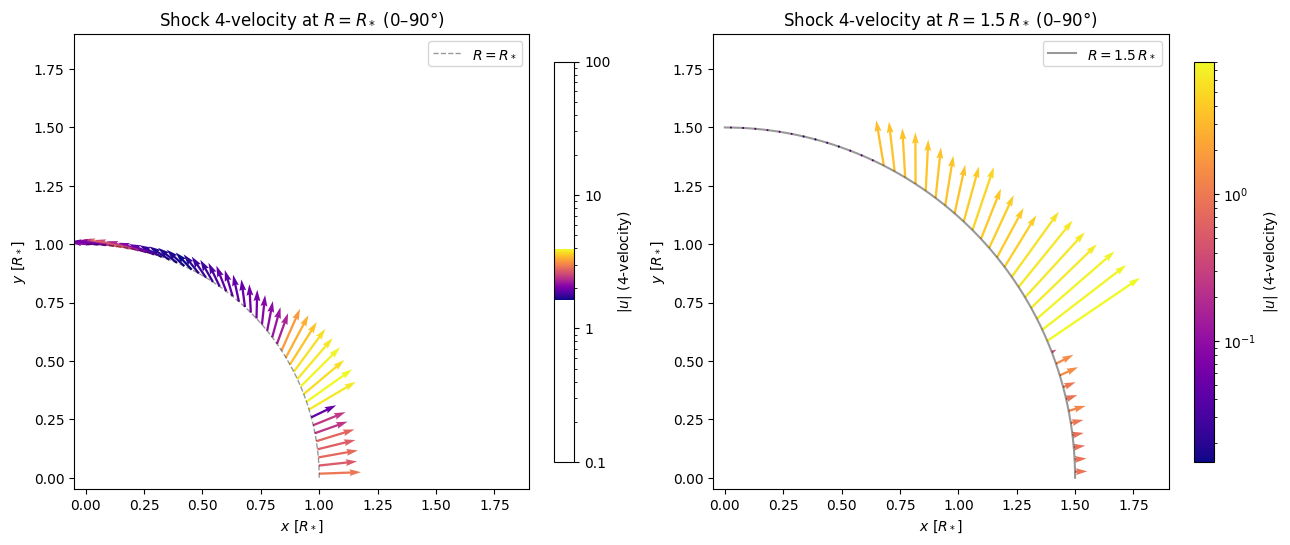

In [17]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

def boundary_arrival_rows(r_tol=0.05, vr_min=0.01):
    """Full shock row (including vr, v_tang) at first R=1.5 boundary arrival per angle."""
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.5) < r_tol) &
            (fronts['vr'] > vr_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

# --- Surface arrival (R=1) ---
arr_surf = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q_surf = arr_surf[(arr_surf['angle_deg'] >= 0) & (arr_surf['angle_deg'] <= 90)].copy()
phi_surf = np.deg2rad(q_surf['angle_deg'].values)
x_surf = np.cos(phi_surf)
y_surf = np.sin(phi_surf)
vr_s  = q_surf['vr'].values
vt_s  = q_surf['v_tang'].values
vx_s  = vr_s * np.cos(phi_surf) - vt_s * np.sin(phi_surf)
vy_s  = vr_s * np.sin(phi_surf) + vt_s * np.cos(phi_surf)
spd_s = np.sqrt(vx_s**2 + vy_s**2)

# --- Boundary arrival (R=1.5) ---
arr = boundary_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)
x_pos = 1.5 * np.cos(phi_q)
y_pos = 1.5 * np.sin(phi_q)
vr  = q['vr'].values
vt  = q['v_tang'].values
vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
spd = np.sqrt(vx**2 + vy**2)

# Separate norms so each panel's colorbar reflects its own data range
norm_s = mcolors.LogNorm(vmin=spd_s[spd_s > 0].min(), vmax=spd_s.max())
norm_b = mcolors.LogNorm(vmin=spd[spd > 0].min(), vmax=spd.max())

# Separate arrow scales so both sets are visually legible
arrow_scale_s = 0.12 / spd_s.max() if spd_s.max() > 0 else 1.0
arrow_scale_b = 0.12 / spd.max()   if spd.max()   > 0 else 1.0

theta_arc = np.linspace(0, np.pi/2, 300)

fig, ax = plt.subplots(1, 2, figsize=(13, 9))
ax[0].plot(np.cos(theta_arc), np.sin(theta_arc),
           'k--', lw=1, alpha=0.4, label=r'$R = R_*$')
ax[1].plot(1.5*np.cos(theta_arc), 1.5*np.sin(theta_arc),
           'k-', lw=1.5, alpha=0.4, label=r'$R = 1.5\,R_*$')

# Surface arrows (R=1)
qv_surf = ax[0].quiver(
    x_surf, y_surf,
    vx_s * arrow_scale_s, vy_s * arrow_scale_s,
    spd_s, cmap='plasma', norm=norm_s,
    angles='xy', scale_units='xy', scale=0.5,
    width=0.005
)

# Boundary arrows (R=1.5)
qv_out = ax[1].quiver(
    x_pos, y_pos,
    vx * arrow_scale_b, vy * arrow_scale_b,
    spd, cmap='plasma', norm=norm_b,
    angles='xy', scale_units='xy', scale=0.25,
    width=0.005
)

cbar_surf = fig.colorbar(qv_surf, ax=ax[0], label=r'$|u|\ \mathrm{(4\text{-}velocity)}$', fraction=0.04)
cbar_out = fig.colorbar(qv_out, ax=ax[1], label=r'$|u|\ \mathrm{(4\text{-}velocity)}$', fraction=0.04)

# Force a labeled tick at u=1 on the surface colorbar (LogLocator won't
# always land exactly on 1 depending on vmin/vmax)
surf_ticks = sorted(set(cbar_surf.get_ticks()) | {1.0})
cbar_surf.set_ticks(surf_ticks)
cbar_surf.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))

ax[0].set_xlim(-0.05, 1.9)
ax[0].set_ylim(-0.05, 1.9)
ax[0].set_aspect('equal')
ax[0].set_xlabel(r'$x\ [R_*]$')
ax[0].set_ylabel(r'$y\ [R_*]$')
ax[0].set_title(r'Shock 4-velocity at $R = R_*$ ($0$–$90°$)')
ax[0].legend(loc='upper right')

ax[1].set_xlim(-0.05, 1.9)
ax[1].set_ylim(-0.05, 1.9)
ax[1].set_aspect('equal')
ax[1].set_xlabel(r'$x\ [R_*]$')
ax[1].set_ylabel(r'$y\ [R_*]$')
ax[1].set_title(r'Shock 4-velocity at $R = 1.5\,R_*$ ($0$–$90°$)')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Video of the whole thing

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(ts[800:1100], start=800):
    r_shock_entropy = []  # list of lists: 1 or more radii per theta

    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock_entropy.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock_entropy.append([1.5])
            # print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height= 100, distance = 10)
        radii = [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2]

        if radii:
            # print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock_entropy.append(radii)
        else:
            r_shock_entropy.append([np.nan])
        # fig, ax = plt.subplots()
        # ax.plot(df_entr['r'], abs_grad, label='Entropy')
        # for r in radii:
        #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
        # ax.set_xlabel(r"$r \ [R_*]$")
        # ax.set_ylabel(r"Entropy $\mathcal{S}$")
        # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds.current_time):.2f}\ R_*/c$") 
        # ax.legend()
        # plt.show()

    # Flatten for polar plot: duplicate theta for entries with two fronts
    plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
    plot_r     = [r  for rs in r_shock_entropy for r in rs]

    plt.figure(figsize=(20, 20))
    plt.polar(plot_theta, plot_r, marker='o', color='g', linestyle='none')
    plt.title(rf"Shock Radius from Entropy Gradient at $t = {float(ds.current_time):.2f}\ R_*/c$")
    plt.savefig(frames_dir / f"frame_{i:04d}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [ ]:
#Now make a video using ffmpeg starting from the first frame frame_1400.png to frame_1499.png
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
import subprocess
subprocess.run(['ffmpeg', '-y', '-framerate', '10', '-start_number', '800', '-i', str(frames_dir / 'frame_%04d.png'), '-c:v', 'libx264', '-pix_fmt', 'yuv420p', '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2', 'shock_evolution.mp4'], check=True)

from IPython.display import Video, display
display(Video('shock_evolution.mp4', embed=True))